# 04 · Split, pipeline, baseline y modelos preliminares
**Proyecto Integrador – Data Mining Tools (CC209)** · TP1

Cubre los **Pasos 6 a 10**: separación de datos sin fuga, pipeline reproducible, baseline, modelos y evaluación.
Entrada: `data/interim/kc_house_clean.csv` (resultado del Paso 5).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INTERIM_FILE = ROOT / "data" / "interim" / "kc_house_clean.csv"
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
FIG = ROOT / "reports" / "figures"
TAB = ROOT / "reports" / "tables"
for d in (PROCESSED, MODELS, FIG, TAB):
    d.mkdir(parents=True, exist_ok=True)


def guardar_fig(nombre):
    plt.savefig(FIG / f"{nombre}.png", dpi=150, bbox_inches="tight")


def ejes_miles(ax, ejes="xy"):
    # Marcas legibles (miles de USD) en ejes logarítmicos
    from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter
    marcas = [100, 200, 400, 800, 1600, 3200, 6400]
    for nombre in ejes:
        eje = ax.xaxis if nombre == "x" else ax.yaxis
        eje.set_major_locator(FixedLocator(marcas))
        eje.set_major_formatter(FuncFormatter(lambda v, _: f"{v:,.0f}"))
        eje.set_minor_formatter(NullFormatter())


pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

df = pd.read_csv(INTERIM_FILE, dtype={"zipcode": "string"}, parse_dates=["fecha"])
print(f"{df.shape[0]:,} filas x {df.shape[1]} columnas")

21,613 filas x 27 columnas


---
## 6. Separación de datos y control de fuga de información

### 6.1 Evidencia previa: ¿tiene sentido un split temporal?

In [2]:
por_mes = (df.groupby(df["fecha"].dt.to_period("M"))["price"]
             .agg(ventas="size", mediana="median").round(0))
por_mes

,ventas,mediana
fecha,,
2014-05,1768,465000.0
2014-06,2180,465000.0
2014-07,2211,465000.0
2014-08,1940,442100.0
2014-09,1774,450000.0
2014-10,1878,446900.0
2014-11,1411,435000.0
2014-12,1471,432500.0
2015-01,978,438500.0


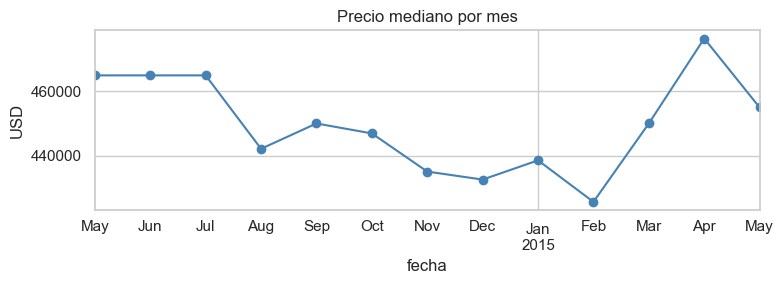

Un test temporal del 15 % final comenzaría el 2015-03-26 y solo cubriría primavera de 2015.
Precio mediano antes / después del corte: 449000.0 / 475000.0


In [3]:
por_mes["mediana"].plot(marker="o", figsize=(8, 3), title="Precio mediano por mes", color="steelblue")
plt.ylabel("USD")
plt.tight_layout()
guardar_fig("split_01_precio_mediano_por_mes")
plt.show()

corte = df["fecha"].quantile(.85)
print(f"Un test temporal del 15 % final comenzaría el {corte.date()} y solo cubriría primavera de 2015.")
print("Precio mediano antes / después del corte:",
      df.loc[df["fecha"] <= corte, "price"].median(), "/", df.loc[df["fecha"] > corte, "price"].median())

**Qué muestran los datos**
- El precio mediano mensual es bastante estable: oscila entre ~426 mil (feb 2015) y ~477 mil (abr 2015), una variación de ±5 % alrededor de 450 mil, con un repunte en primavera.
- Un split temporal dejaría como test solo las ventas desde fines de marzo de 2015 (mediana 475 mil, contra 449 mil antes).

**Decisión: split aleatorio agrupado por `id`, no temporal.**

**Justificación**
- Con solo ~13 meses no hay tendencia de largo plazo que el test deba medir, y el nivel de precios es estable.
- Un test temporal mediría el desempeño en una sola estación (primavera) y se confundiría con la estacionalidad.
- El modelo no usa la fecha como predictor (ver 6.4), por lo que no necesita extrapolar en el tiempo.

**Riesgo declarado:** un split aleatorio no mide qué tan bien funcionaría el modelo con ventas **futuras**. Este es un límite del dato y se menciona en las conclusiones. En el TF1 se puede añadir una validación temporal como prueba de robustez.

### 6.2 Estrategia: train / validation / test = 70 / 15 / 15, agrupado por `id`

| Partición | Uso |
|---|---|
| **Train (70 %)** | Ajustar transformaciones y modelos |
| **Validation (15 %)** | Comparar modelos y decidir (se puede consultar muchas veces) |
| **Test (15 %)** | Evaluación final, **una sola vez** |

**Por qué 70/15/15:** con ~21.6 mil filas, 15 % deja ~3 200 ventas para validación y para test, suficientes para métricas estables. Separar validación evita decidir con el test.

**Por qué agrupado por `id`:** una misma vivienda puede aparecer hasta 3 veces. Si quedara en *train* y en *test*, el modelo se evaluaría con casas que ya vio y el error parecería menor al real. `GroupShuffleSplit` mantiene todas las ventas de un `id` en la misma partición.

In [4]:
# 1) Se separa el test (15 %)
g1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
idx_trainval, idx_test = next(g1.split(df, groups=df["id"]))

# 2) Del resto se separa validation (15 % del total = 0.15 / 0.85 del resto)
sub = df.iloc[idx_trainval]
g2 = GroupShuffleSplit(n_splits=1, test_size=0.15 / 0.85, random_state=RANDOM_STATE)
rel_train, rel_val = next(g2.split(sub, groups=sub["id"]))
idx_train, idx_val = idx_trainval[rel_train], idx_trainval[rel_val]

split = pd.Series("", index=df.index, name="split")
split.iloc[idx_train] = "train"
split.iloc[idx_val] = "val"
split.iloc[idx_test] = "test"

resumen = split.value_counts().rename("filas").to_frame()
resumen["proporción"] = (resumen["filas"] / len(df)).round(3)
resumen.loc[["train", "val", "test"]]

,filas,proporción
split,,
train,15130,0.70
val,3242,0.15
test,3241,0.15


### 6.3 Verificaciones anti-fuga

In [5]:
ids = df.groupby(split)["id"].apply(set)
solapes = {
    "train ∩ val": len(ids["train"] & ids["val"]),
    "train ∩ test": len(ids["train"] & ids["test"]),
    "val ∩ test": len(ids["val"] & ids["test"]),
}
print("id compartidos entre particiones:", solapes)
assert all(v == 0 for v in solapes.values()), "Hay fuga: un id aparece en dos particiones"

rep = df[df["id"].duplicated(keep=False)]
n_dividido = (rep.groupby("id").apply(lambda g: split[g.index].nunique()) > 1).sum()
print("Viviendas repetidas repartidas en más de una partición:", n_dividido)
assert n_dividido == 0

zip_train = set(df.loc[split == "train", "zipcode"])
for nombre in ["val", "test"]:
    fuera = df[(split == nombre) & ~df["zipcode"].isin(zip_train)]
    print(f"{nombre}: filas con zipcode ausente en train = {len(fuera)}")

id compartidos entre particiones: {'train ∩ val': 0, 'train ∩ test': 0, 'val ∩ test': 0}
Viviendas repetidas repartidas en más de una partición: 0
val: filas con zipcode ausente en train = 0
test: filas con zipcode ausente en train = 0


### 6.4 ¿Las particiones son comparables?

In [6]:
comparacion = df.groupby(split)["price"].describe(percentiles=[.1, .5, .9]).loc[["train", "val", "test"]]
display(comparacion[["count", "mean", "10%", "50%", "90%", "max"]].round(0))

otras = df.groupby(split).agg(
    waterfront=("waterfront", "mean"),
    sqft_living_mediana=("sqft_living", "median"),
    dato_dudoso=("dato_dudoso", "sum"),
).loc[["train", "val", "test"]]
otras["waterfront"] = otras["waterfront"].round(4)
resumen.loc[["train", "val", "test"]].to_csv(TAB / "split_tamanos.csv")
comparacion[["count", "mean", "10%", "50%", "90%", "max"]].round(0).to_csv(TAB / "split_comparacion_precio.csv")
otras

,count,mean,10%,50%,90%,max
split,,,,,,
train,15130.0,538673.0,246690.0,450000.0,880000.0,7700000.0
val,3242.0,533999.0,245000.0,445975.0,870000.0,4668000.0
test,3241.0,552785.0,244000.0,453000.0,921000.0,6885000.0


,waterfront,sqft_living_mediana,dato_dudoso
split,,,
train,0.0073,1920.0,5
val,0.0093,1880.0,4
test,0.0071,1920.0,1


**Qué muestran los datos**
- Tamaños: **15 130** (train), **3 242** (val) y **3 241** (test), es decir 70/15/15.
- **Ningún `id` aparece en más de una partición**, y las 176 viviendas repetidas quedaron completas en una sola.
- Todos los códigos postales de validación y test existen en train.
- La mediana del precio es parecida entre particiones (~446 mil a 453 mil). La media del test (553 mil) es algo mayor que la de train (539 mil) porque contiene algunas ventas muy caras. El precio máximo de todo el dataset (7.7 millones) cayó en train.

**Interpretación**
- Las diferencias de media son esperables en una muestra con cola larga y no indican un split defectuoso. Aun así, se debe recordar que las métricas en dólares de test pueden verse algo afectadas por pocos casos extremos; por eso se usarán también métricas relativas.
- No se estratificó por precio ni por zona: el tamaño de cada partición y la cobertura de zonas hacen que no sea necesario. Es una decisión revisable.

**Variables fuera de los predictores (control de fuga)**
- `id`: solo sirve para agrupar.
- `fecha`, `anio_venta`, `mes_venta`: no se usan; con 13 meses el modelo no podría generalizar un efecto temporal y se confundiría con estacionalidad.
- `dato_dudoso`: es un indicador de calidad de datos, no una característica de la vivienda.
- No existe ninguna variable derivada del precio (se descartó `precio_por_pie2` en el Paso 5).

In [7]:
split.rename_axis("fila").reset_index().to_csv(PROCESSED / "split.csv", index=False)
print("Índices guardados en", (PROCESSED / "split.csv").relative_to(ROOT))

Índices guardados en data\processed\split.csv


**Reglas de uso a partir de aquí**
1. Todo ajuste (imputación, escalado, codificación, modelos) usa **solo train**.
2. **Validation** se usa para comparar y decidir.
3. **Test** no se usa para ajustar ni para decidir; solo se mide en la evaluación final del Paso 10. (En 6.4 solo se compararon estadísticas descriptivas del precio, sin tomar decisiones de modelado a partir de ellas.)
4. La partición es reproducible: `RANDOM_STATE = 42` y los índices están en `data/processed/split.csv`.

---
## 7. Pipeline reproducible de preprocesamiento

### 7.1 Qué se hace con cada variable

| Grupo | Variables | Transformación | Por qué |
|---|---|---|---|
| Superficies (asimétricas) | `sqft_living`, `sqft_lot`, `sqft_above`, `sqft_basement`, `sqft_living15`, `sqft_lot15` | `log1p` → `StandardScaler` | Asimetría alta (EDA 4.2); `log1p` admite el 0 de `sqft_basement` |
| Conteos con faltantes | `bedrooms`, `bathrooms` | `SimpleImputer(mediana)` → `StandardScaler` | 10 y 5 faltantes creados en el Paso 5; la mediana se calcula **solo con train** |
| Numéricas / ordinales | `floors`, `view`, `condition`, `grade`, `antiguedad`, `lat`, `long` | `StandardScaler` | Escala comparable para el modelo lineal |
| Binarias | `waterfront`, `renovada`, `tiene_sotano` | Sin cambios | Ya son 0/1 |
| Categórica | `zipcode` | `OneHotEncoder(handle_unknown="ignore")` | Es una categoría de 70 niveles; un código desconocido no rompe la predicción |
| **Objetivo** | `price` | `log` al ajustar, `exp` al predecir | Asimetría 4.0 → 0.43 (EDA 4.1) |
| **Excluidas** | `id`, `fecha`, `anio_venta`, `mes_venta`, `dato_dudoso`, `yr_built`, `yr_renovated` | — | Ver 6.4. `yr_built` y `yr_renovated` quedan representadas por `antiguedad` y `renovada` |

**Cuándo se ajusta cada cosa:** todos los parámetros (medianas, medias, desviaciones, categorías) se aprenden en `fit` con **train**. Validation y test solo pasan por `transform`.

**Un solo preprocesador para todos los modelos:** el `log1p` y el escalado no afectan a los modelos de árboles, y usar el mismo flujo garantiza una comparación justa entre modelos.

In [8]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

COLS_LOG = ["sqft_living", "sqft_lot", "sqft_above", "sqft_basement", "sqft_living15", "sqft_lot15"]
COLS_IMPUTAR = ["bedrooms", "bathrooms"]
COLS_NUM = ["floors", "view", "condition", "grade", "antiguedad", "lat", "long"]
COLS_BIN = ["waterfront", "renovada", "tiene_sotano"]
COLS_CAT = ["zipcode"]
FEATURES = COLS_LOG + COLS_IMPUTAR + COLS_NUM + COLS_BIN + COLS_CAT
TARGET = "price"


def crear_preprocesador():
    return ColumnTransformer(
        transformers=[
            ("log", Pipeline([
                ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                ("escala", StandardScaler()),
            ]), COLS_LOG),
            ("imputar", Pipeline([
                ("imputador", SimpleImputer(strategy="median")),
                ("escala", StandardScaler()),
            ]), COLS_IMPUTAR),
            ("num", StandardScaler(), COLS_NUM),
            ("bin", "passthrough", COLS_BIN),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), COLS_CAT),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def crear_pipeline(estimador):
    """Preprocesamiento + modelo, con objetivo en escala log."""
    return TransformedTargetRegressor(
        regressor=Pipeline([("prep", crear_preprocesador()), ("modelo", estimador)]),
        func=np.log,
        inverse_func=np.exp,
    )


mask_train = (split == "train").to_numpy()
mask_val = (split == "val").to_numpy()
mask_test = (split == "test").to_numpy()

X_train, y_train = df.loc[mask_train, FEATURES], df.loc[mask_train, TARGET]
X_val, y_val = df.loc[mask_val, FEATURES], df.loc[mask_val, TARGET]
X_test, y_test = df.loc[mask_test, FEATURES], df.loc[mask_test, TARGET]

print("Predictores:", len(FEATURES), "| train:", X_train.shape, "| val:", X_val.shape, "| test:", X_test.shape)

Predictores:

 19 | train: (15130, 19) | val: (3242, 19) | test: (3241, 19)


### 7.2 Verificaciones del pipeline

In [9]:
prep = crear_preprocesador()
Xt_train = prep.fit_transform(X_train)          # fit SOLO con train
Xt_val = prep.transform(X_val)                  # val: solo transform
Xt_test = prep.transform(X_test)                # test: solo transform

nombres = prep.get_feature_names_out()
print("Columnas tras el preprocesamiento:", len(nombres), "(6 log + 2 imputadas + 7 num + 3 bin + 70 zipcode)")
print("Formas  train / val / test:", Xt_train.shape, Xt_val.shape, Xt_test.shape)
print("NaN tras el preprocesamiento:", int(np.isnan(Xt_train).sum() + np.isnan(Xt_val).sum() + np.isnan(Xt_test).sum()))

Columnas tras el preprocesamiento: 88 (6 log + 2 imputadas + 7 num + 3 bin + 70 zipcode)
Formas  train / val / test: (15130, 88) (3242, 88) (3241, 88)
NaN tras el preprocesamiento: 0


In [10]:
# Los parámetros aprendidos vienen de train, no del dataset completo
mediana_train = X_train["bedrooms"].median()
mediana_todo = df["bedrooms"].median()
imputador = prep.named_transformers_["imputar"].named_steps["imputador"]
print("Mediana de bedrooms usada por el imputador:", imputador.statistics_[0], "| mediana de train:", mediana_train)

escala = prep.named_transformers_["log"].named_steps["escala"]
media_train = np.log1p(X_train["sqft_living"]).mean()
media_todo = np.log1p(df["sqft_living"]).mean()
print(f"Media de log1p(sqft_living) usada: {escala.mean_[0]:.6f} | train: {media_train:.6f} | dataset completo: {media_todo:.6f}")
assert np.isclose(escala.mean_[0], media_train)
assert not np.isclose(escala.mean_[0], media_todo, atol=1e-9), "Los parámetros coinciden con el dataset completo: posible fuga"

# Un código postal nunca visto no debe romper la predicción
nuevo = X_train.iloc[[0]].copy()
nuevo["zipcode"] = "99999"
print("Código postal desconocido -> columnas zipcode activas:", int(prep.transform(nuevo)[:, -70:].sum()))

Mediana de bedrooms usada por el imputador: 3.0 | mediana de train: 3.0
Media de log1p(sqft_living) usada: 7.551356 | train: 7.551356 | dataset completo: 7.550910
Código postal desconocido -> columnas zipcode activas: 0


**Qué muestran los datos**
- El preprocesamiento produce **88 columnas** (18 numéricas/binarias + 70 de `zipcode`), sin ningún `NaN`.
- El imputador usa la mediana de **train** (3.0), que coincide con la del dataset completo; por eso esa comparación no prueba nada por sí sola.
- La prueba concluyente es la del escalador: su media de `log1p(sqft_living)` es 7.551356, igual a la de train y distinta de la del dataset completo (7.550910). La diferencia es pequeña, pero confirma que el ajuste no usó validation ni test.
- Un código postal desconocido produce un vector de ceros en `zipcode` en vez de un error.

**Interpretación**
- El flujo es reproducible: todo el preprocesamiento está en un objeto único (`ColumnTransformer` dentro de un `Pipeline`), y el objetivo se transforma con `TransformedTargetRegressor`. Al predecir se devuelve el precio en USD.
- Como el imputador y el escalador son parte del pipeline, la validación cruzada del TF1 volverá a ajustarlos en cada pliegue sin esfuerzo adicional.

**Riesgo:** `zipcode` con *one-hot* agrega 70 columnas dispersas. Funciona bien con modelos lineales regularizados y con Random Forest, pero se revisará si estorba (por ejemplo, para XGBoost) o si conviene reemplazarlo por `lat`/`long` o por zonas de clustering (TF1).

---
## 8. Baseline

> *¿El modelo propuesto mejora realmente frente a una solución trivial o simple?*

Se comparan tres referencias de dificultad creciente. **La más fuerte es la que cualquier modelo debe superar.**

| Baseline | Qué hace | Para qué sirve |
|---|---|---|
| **B1 · Mediana global** | Predice siempre el precio mediano de train | Piso absoluto: "sin información" |
| **B2 · Lineal simple** | Regresión de `log(price)` sobre `log1p(sqft_living)` | ¿Basta con el tamaño? |
| **B3 · Regla por zona** | Precio por pie² mediano del código postal (de train) × `sqft_living` | Regla de tasación realista: zona + tamaño |

### 8.1 Métricas
| Métrica | Por qué |
|---|---|
| **MAE** (USD) | Error absoluto promedio, fácil de interpretar |
| **RMSE** (USD) | Penaliza más los errores grandes (ventas caras) |
| **R²** (USD) y **R²** (log) | Proporción de variación explicada, en dólares y en escala log |
| **MdAPE** (%) | **Error porcentual mediano.** Es la métrica del criterio de utilidad (≤ 15 %); un error en dólares engaña entre casas de 150 mil y de 3 millones |
| **% dentro de ±20 %** | Proporción de ventas estimadas con un error relativo menor a 20 % |

In [11]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluar(y_real, y_pred):
    y_real, y_pred = np.asarray(y_real, float), np.asarray(y_pred, float)
    ape = np.abs(y_pred - y_real) / y_real
    return {
        "MAE (USD)": mean_absolute_error(y_real, y_pred),
        "RMSE (USD)": np.sqrt(mean_squared_error(y_real, y_pred)),
        "R² (USD)": r2_score(y_real, y_pred),
        "R² (log)": r2_score(np.log(y_real), np.log(y_pred)),
        "MdAPE (%)": 100 * np.median(ape),
        "± 20 % (%)": 100 * np.mean(ape <= 0.20),
    }


resultados_val = {}
pred_val = {}

In [12]:
# B1 · Mediana global (la mediana se calcula con train)
b1 = crear_pipeline(DummyRegressor(strategy="median")).fit(X_train, y_train)
pred_val["B1 · Mediana global"] = b1.predict(X_val)

# B2 · Lineal simple sobre log1p(sqft_living)
b2 = TransformedTargetRegressor(
    regressor=Pipeline([
        ("x", ColumnTransformer([("tam", FunctionTransformer(np.log1p), ["sqft_living"])])),
        ("lineal", LinearRegression()),
    ]),
    func=np.log, inverse_func=np.exp,
).fit(X_train, y_train)
pred_val["B2 · Lineal simple (sqft_living)"] = b2.predict(X_val)

# B3 · Regla por zona: precio por pie² mediano del código postal (train) × sqft_living
ppp_zona = (y_train / X_train["sqft_living"]).groupby(X_train["zipcode"]).median()
ppp_global = (y_train / X_train["sqft_living"]).median()
def regla_zona(X):
    return X["zipcode"].map(ppp_zona).fillna(ppp_global).to_numpy() * X["sqft_living"].to_numpy()
pred_val["B3 · Regla por zona (USD/pie² × tamaño)"] = regla_zona(X_val)

for nombre, p in pred_val.items():
    resultados_val[nombre] = evaluar(y_val, p)

pd.DataFrame(resultados_val).T.round(2)

,MAE (USD),RMSE (USD),R² (USD),R² (log),MdAPE (%),± 20 % (%)
B1 · Mediana global,219515.32,368055.03,-0.05,-0.00,34.31,29.89
B2 · Lineal simple (sqft_living),166401.25,273689.11,0.42,0.46,26.23,38.25
B3 · Regla por zona (USD/pie² × tamaño),100340.24,173632.26,0.77,0.78,14.29,64.22


**Qué muestran los datos (validation)**

| Baseline | MAE | MdAPE | R² (USD) | ± 20 % |
|---|---|---|---|---|
| B1 · Mediana global | 219 515 | 34.3 % | −0.05 | 29.9 % |
| B2 · Lineal simple | 166 401 | 26.2 % | 0.42 | 38.3 % |
| **B3 · Regla por zona** | **100 340** | **14.3 %** | **0.77** | **64.2 %** |

- B1 no explica nada (R² ≈ 0) y se equivoca 34 % en la mediana: es el piso esperado.
- Solo con el tamaño (B2) el error mediano baja a 26 %.
- Agregar la **zona** (B3) reduce el MAE a la mitad de B2 (166 mil → 100 mil) y el error mediano a 14.3 %.

**Interpretación**
- Tamaño y ubicación explican la mayor parte del precio: una regla de dos ingredientes ya llega a R² 0.77. **B3 es el baseline que hay que superar.**
- Esto confirma con datos el hallazgo del EDA sobre el peso de la ubicación.

### 8.2 Revisión del criterio de utilidad del Paso 2
El Paso 2 fijó MdAPE ≤ 15 % como umbral y avisó que se revisaría con la evidencia del baseline.

- **Evidencia:** B3, una regla sin modelo de aprendizaje, ya logra **14.3 %**. El umbral de 15 % **no demuestra que un modelo aporte valor**.
- **Qué criterio manda:** el de *mejora sobre el baseline más fuerte (B3)*. Antes de ver ningún modelo se fija su definición operativa:

> **Un modelo se considera útil si, en validation, reduce el MAE y el MdAPE de B3 en al menos un 15 % relativo** (es decir, MAE ≤ ~85 mil y MdAPE ≤ ~12.1 %).

- El 15 % relativo, medido sobre MAE y MdAPE a la vez, fue **aceptado por el grupo**. El umbral absoluto de MdAPE ≤ 15 % se mantiene como requisito mínimo, no como prueba de utilidad.

---
## 9. Modelos preliminares

Tres modelos con el **mismo pipeline, mismo split y misma semilla**. Hiperparámetros por defecto o casi por defecto: la optimización sistemática (Optuna, MLflow) es del TF1.

| Modelo | Por qué se incluye |
|---|---|
| **Ridge** | Referencia lineal e interpretable. La regularización controla la multicolinealidad (`sqft_above` / `sqft_living`) y las 70 columnas de `zipcode` |
| **Random Forest** | Captura relaciones no lineales e interacciones (por ejemplo, tamaño × zona) y no necesita escalar |
| **XGBoost** | Boosting de árboles, habitual en datos tabulares; permite comparar dos familias de árboles |

In [13]:
import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

modelos = {
    "Ridge": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=5,
                            random_state=RANDOM_STATE, n_jobs=-1),
}

ajustados = {}
tiempos = {}
for nombre, est in modelos.items():
    t0 = time.perf_counter()
    ajustados[nombre] = crear_pipeline(est).fit(X_train, y_train)      # fit solo con train
    tiempos[nombre] = time.perf_counter() - t0
    pred_val[nombre] = ajustados[nombre].predict(X_val)
    resultados_val[nombre] = evaluar(y_val, pred_val[nombre])

tabla_val = pd.DataFrame(resultados_val).T
tabla_val["tiempo ajuste (s)"] = pd.Series(tiempos)
tabla_val.round(2).to_csv(TAB / "modelos_metricas_validation.csv")
tabla_val.round(2)

,MAE (USD),RMSE (USD),R² (USD),R² (log),MdAPE (%),± 20 % (%),tiempo ajuste (s)
B1 · Mediana global,219515.32,368055.03,-0.05,-0.00,34.31,29.89,NaN
B2 · Lineal simple (sqft_living),166401.25,273689.11,0.42,0.46,26.23,38.25,NaN
B3 · Regla por zona (USD/pie² × tamaño),100340.24,173632.26,0.77,0.78,14.29,64.22,NaN
Ridge,73487.42,126817.49,0.87,0.88,10.08,78.62,0.03
Random Forest,69894.45,131481.02,0.87,0.88,8.73,80.91,3.87
XGBoost,64948.68,112824.07,0.90,0.89,8.73,82.23,0.45


### 9.1 ¿Las diferencias entre modelos son reales o ruido?
Con ~3 200 ventas de validación, una diferencia pequeña puede deberse al azar. Se remuestrea validation (*bootstrap*, 1 000 réplicas) para estimar intervalos del 95 %.

In [14]:
rng = np.random.default_rng(RANDOM_STATE)
yv = y_val.to_numpy()
n = len(yv)
nombres_m = ["Ridge", "Random Forest", "XGBoost"]
ape = {m: np.abs(pred_val[m] - yv) / yv for m in nombres_m}
ae = {m: np.abs(pred_val[m] - yv) for m in nombres_m}

B = 1000
boot = {m: {"MdAPE": [], "MAE": []} for m in nombres_m}
for _ in range(B):
    i = rng.integers(0, n, n)
    for m in nombres_m:
        boot[m]["MdAPE"].append(100 * np.median(ape[m][i]))
        boot[m]["MAE"].append(ae[m][i].mean())

ic = lambda a: tuple(float(x) for x in np.percentile(a, [2.5, 97.5]).round(2))
print("Intervalo 95 % por modelo")
intervalos = pd.DataFrame({m: {"MdAPE (%)": ic(boot[m]["MdAPE"]), "MAE (USD)": ic(boot[m]["MAE"])} for m in nombres_m}).T
intervalos.to_csv(TAB / "modelos_intervalos_bootstrap_validation.csv")
display(intervalos)

pares = [("Random Forest", "Ridge"), ("XGBoost", "Ridge"), ("XGBoost", "Random Forest")]
filas = []
for a, b in pares:
    d_md = np.array(boot[a]["MdAPE"]) - np.array(boot[b]["MdAPE"])
    d_ma = np.array(boot[a]["MAE"]) - np.array(boot[b]["MAE"])
    filas.append({"comparación (A − B)": f"{a} − {b}",
                  "Δ MdAPE (pts)": f"{d_md.mean():.2f}  {ic(d_md)}",
                  "Δ MAE (USD)": f"{d_ma.mean():,.0f}  {tuple(int(x) for x in np.percentile(d_ma, [2.5, 97.5]))}"})
comparaciones = pd.DataFrame(filas).set_index("comparación (A − B)")
comparaciones.to_csv(TAB / "modelos_diferencias_bootstrap_validation.csv")
comparaciones

Intervalo 95 % por modelo


,MdAPE (%),MAE (USD)
Ridge,"(9.57, 10.5)","(70023.03, 77229.55)"
Random Forest,"(8.25, 9.11)","(66200.35, 73777.71)"
XGBoost,"(8.36, 9.07)","(61941.73, 68334.6)"


,Δ MdAPE (pts),Δ MAE (USD)
comparación (A − B),,
Random Forest − Ridge,"-1.34 (-1.86, -0.81)","-3,572 (-5934, -1033)"
XGBoost − Ridge,"-1.34 (-1.83, -0.85)","-8,505 (-10591, -6534)"
XGBoost − Random Forest,"-0.00 (-0.35, 0.38)","-4,933 (-7123, -2806)"


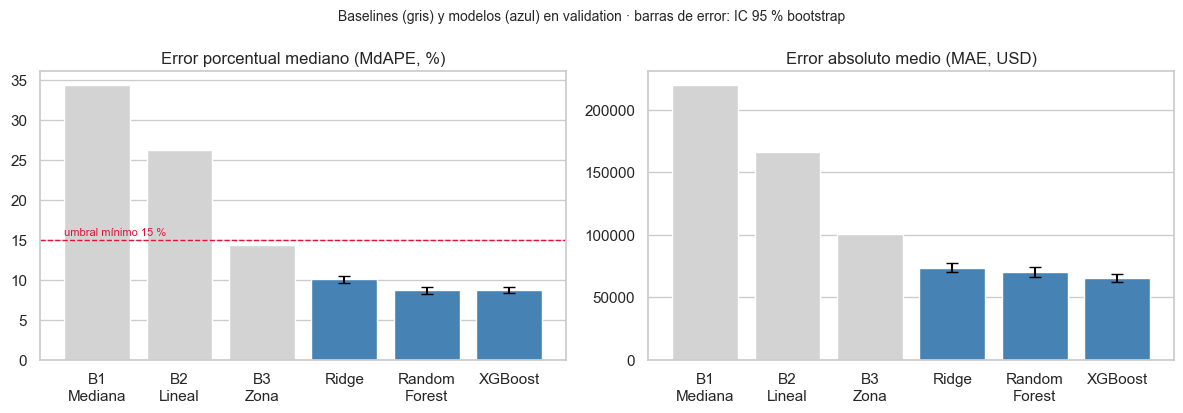

In [15]:
orden = list(resultados_val.keys())
etiquetas = ["B1\nMediana", "B2\nLineal", "B3\nZona", "Ridge", "Random\nForest", "XGBoost"]
colores = ["lightgray"] * 3 + ["steelblue"] * 3

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, metrica, boot_key, titulo in [(axes[0], "MdAPE (%)", "MdAPE", "Error porcentual mediano (MdAPE, %)"),
                                      (axes[1], "MAE (USD)", "MAE", "Error absoluto medio (MAE, USD)")]:
    vals = [resultados_val[k][metrica] for k in orden]
    ax.bar(etiquetas, vals, color=colores)
    for j, m in enumerate(nombres_m):
        lo, hi = np.percentile(boot[m][boot_key], [2.5, 97.5])
        ax.errorbar(3 + j, vals[3 + j], yerr=[[vals[3 + j] - lo], [hi - vals[3 + j]]], color="black", capsize=4)
    ax.set_title(titulo)
    ax.grid(axis="x", visible=False)
axes[0].axhline(15, color="crimson", ls="--", lw=1)
axes[0].text(-0.4, 15.5, "umbral mínimo 15 %", color="crimson", fontsize=8)
fig.suptitle("Baselines (gris) y modelos (azul) en validation · barras de error: IC 95 % bootstrap", fontsize=10)
plt.tight_layout()
guardar_fig("modelo_01_comparacion_validation")
plt.show()

**Qué muestran los datos (validation)**

| Modelo | MAE (USD) | MdAPE | R² (USD) | ± 20 % |
|---|---|---|---|---|
| B3 · Regla por zona (mejor baseline) | 100 340 | 14.3 % | 0.77 | 64.2 % |
| Ridge | 73 487 | 10.1 % | 0.87 | 78.6 % |
| Random Forest | 69 894 | 8.7 % | 0.87 | 80.9 % |
| XGBoost | 64 949 | 8.7 % | 0.90 | 82.2 % |

- **Los tres modelos superan al mejor baseline.** Reducen el MAE entre 27 % y 35 % y el MdAPE entre 29 % y 39 % respecto de B3, por encima del 15 % relativo exigido en 8.2.
- **Árboles frente a Ridge:** la mejora es real. Random Forest y XGBoost bajan el MdAPE en ~1.3 puntos respecto de Ridge, con un intervalo del 95 % que no incluye 0 (−1.9 a −0.8 y −1.8 a −0.9).
- **XGBoost frente a Random Forest:** **empatan en MdAPE** (diferencia ≈ 0, intervalo −0.35 a +0.38). XGBoost tiene un MAE menor, unos 4 900 USD, y su intervalo (−7 100 a −2 800) no incluye 0.
- XGBoost ajusta en 0.6 s y Random Forest en 3.9 s.

**Interpretación**
- Ridge, un modelo lineal, ya logra cerca de tres cuartas partes de la mejora de XGBoost sobre el baseline (27 % de 35 % en MAE). Los árboles añaden una mejora adicional moderada, plausiblemente por capturar interacciones y no linealidades (por ejemplo, el efecto del tamaño depende de la zona). Es una hipótesis: no se probó qué interacciones aprovechan.
- Entre los dos modelos de árboles, la ventaja de XGBoost aparece en el error en dólares (que pesa más las ventas caras), no en el error relativo mediano. Esto sugiere, como hipótesis, que mejora sobre todo en las casas de mayor precio; se comprueba por rango de precio en el Paso 10.
- Los intervalos provienen de una sola partición de validación; no sustituyen a una validación cruzada, que se hará en el TF1.

**Regla de selección (fijada antes de mirar el test):** el modelo final es el de **menor MdAPE en validation**; si la diferencia es menor a 0.1 puntos, se elige el de **menor MAE**.
Con esa regla gana **XGBoost**: empata en MdAPE con Random Forest y tiene menor MAE.

---
## 10. Evaluación preliminar

Primero se analiza el comportamiento en **validation** (se puede consultar libremente). El **test se evalúa una sola vez**, al final, con el modelo ya elegido.

### 10.1 Real frente a predicho y distribución del error (validation, XGBoost)

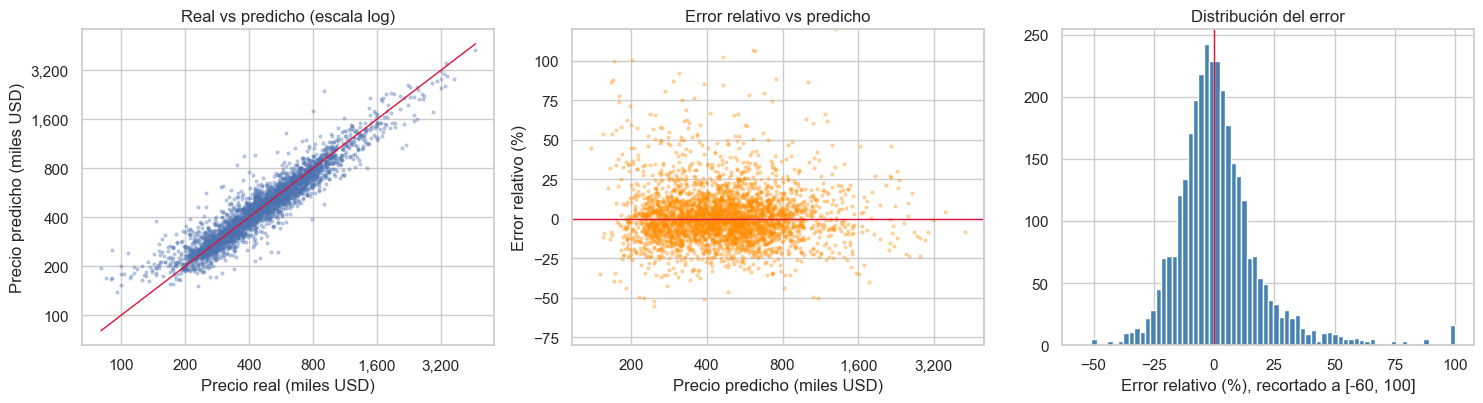

Error relativo con signo: mediana -0.55 % | media +1.94 %
Percentiles 5 / 25 / 75 / 95: [-22.0, -8.6, 8.9, 33.3]
Sobreestima (> +20 %): 11.0% | subestima (< -20 %): 6.8%


In [16]:
elegido = "XGBoost"
pv = pred_val[elegido]
err_rel = (pv - yv) / yv * 100          # error relativo con signo (%)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].scatter(yv / 1e3, pv / 1e3, s=4, alpha=.3)
lim = [yv.min() / 1e3, yv.max() / 1e3]
axes[0].plot(lim, lim, color="crimson", lw=1)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Precio real (miles USD)"); axes[0].set_ylabel("Precio predicho (miles USD)")
axes[0].set_title("Real vs predicho (escala log)"); ejes_miles(axes[0], "xy")

axes[1].scatter(pv / 1e3, err_rel, s=4, alpha=.3, color="darkorange")
axes[1].axhline(0, color="crimson", lw=1)
axes[1].set_xscale("log"); axes[1].set_ylim(-80, 120)
axes[1].set_xlabel("Precio predicho (miles USD)"); axes[1].set_ylabel("Error relativo (%)")
axes[1].set_title("Error relativo vs predicho"); ejes_miles(axes[1], "x")

axes[2].hist(err_rel.clip(-60, 100), bins=70, color="steelblue")
axes[2].axvline(0, color="crimson", lw=1)
axes[2].set_xlabel("Error relativo (%), recortado a [-60, 100]"); axes[2].set_title("Distribución del error")
plt.tight_layout()
guardar_fig("modelo_02_real_vs_predicho_validation")
plt.show()

print(f"Error relativo con signo: mediana {np.median(err_rel):+.2f} % | media {err_rel.mean():+.2f} %")
print(f"Percentiles 5 / 25 / 75 / 95: {np.percentile(err_rel, [5, 25, 75, 95]).round(1).tolist()}")
print(f"Sobreestima (> +20 %): {(err_rel > 20).mean():.1%} | subestima (< -20 %): {(err_rel < -20).mean():.1%}")

### 10.2 ¿Dónde falla más? Por rango de precio y por zona (validation)
Análisis rápido; el análisis profundo de errores es del TF1.

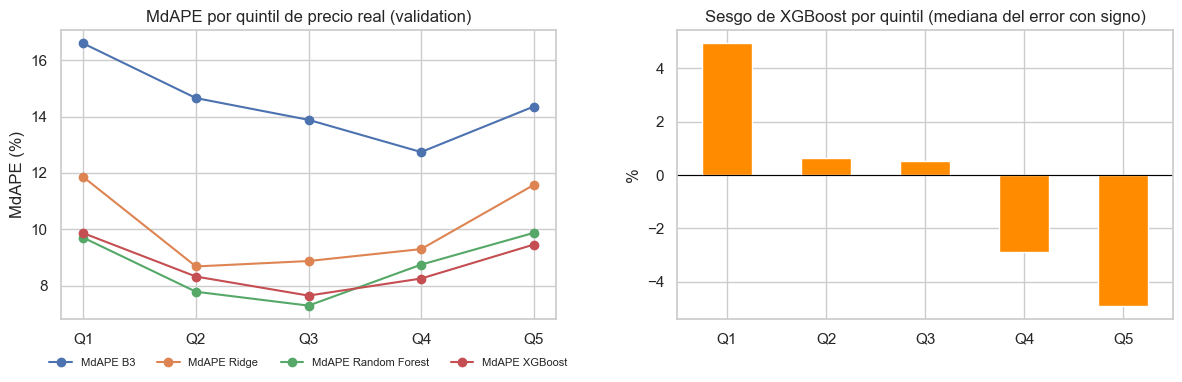

,rango real (miles USD),MdAPE B3,MdAPE Ridge,MdAPE Random Forest,MdAPE XGBoost,sesgo XGBoost (%),MAE XGBoost (USD)
Q1 (más baratas),80 – 291,16.6,11.9,9.7,9.9,4.9,35132.0
Q2,292 – 395,14.7,8.7,7.8,8.3,0.6,40673.8
Q3,396 – 516,13.9,8.9,7.3,7.6,0.5,47840.0
Q4,516 – 700,12.7,9.3,8.7,8.2,-2.9,63327.8
Q5 (más caras),"701 – 4,668",14.4,11.6,9.9,9.5,-4.9,139127.1


In [17]:
quintil = pd.qcut(y_val, 5, labels=["Q1 (más baratas)", "Q2", "Q3", "Q4", "Q5 (más caras)"])
filas = []
for q in quintil.cat.categories:
    m = (quintil == q).to_numpy()
    fila = {"rango real (miles USD)": f"{yv[m].min()/1e3:,.0f} – {yv[m].max()/1e3:,.0f}"}
    for nombre in ["B3 · Regla por zona (USD/pie² × tamaño)", "Ridge", "Random Forest", "XGBoost"]:
        fila[f"MdAPE {nombre.split(' ·')[0]}"] = 100 * np.median(np.abs(pred_val[nombre][m] - yv[m]) / yv[m])
    fila["sesgo XGBoost (%)"] = np.median((pred_val["XGBoost"][m] - yv[m]) / yv[m]) * 100
    fila["MAE XGBoost (USD)"] = np.abs(pred_val["XGBoost"][m] - yv[m]).mean()
    filas.append(pd.Series(fila, name=q))
por_rango = pd.DataFrame(filas)
por_rango.round(1).to_csv(TAB / "modelos_error_por_rango_precio_validation.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cols_md = [c for c in por_rango.columns if c.startswith("MdAPE")]
por_rango[cols_md].plot(marker="o", ax=axes[0])
axes[0].set_title("MdAPE por quintil de precio real (validation)")
axes[0].set_ylabel("MdAPE (%)"); axes[0].set_xticks(range(5)); axes[0].set_xticklabels(["Q1", "Q2", "Q3", "Q4", "Q5"])
axes[0].legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=4, frameon=False)
axes[1].grid(axis="x", visible=False)
por_rango["sesgo XGBoost (%)"].plot.bar(ax=axes[1], color="darkorange")
axes[1].axhline(0, color="black", lw=.8)
axes[1].set_title("Sesgo de XGBoost por quintil (mediana del error con signo)")
axes[1].set_ylabel("%"); axes[1].set_xticklabels(["Q1", "Q2", "Q3", "Q4", "Q5"], rotation=0)
plt.tight_layout()
guardar_fig("modelo_03_error_por_rango_precio")
plt.show()
por_rango.round(1)

In [18]:
va = X_val.assign(real=yv, pred=pv, ape=np.abs(pv - yv) / yv * 100)
por_zona = (va.groupby("zipcode")
              .agg(ventas=("real", "size"), MdAPE=("ape", "median"), mediana_precio=("real", "median"))
              .query("ventas >= 20").sort_values("MdAPE"))
por_zona.round(1).to_csv(TAB / "modelos_error_por_zipcode_validation.csv")
print(f"Códigos postales con ≥ 20 ventas en validation: {len(por_zona)}")
display(pd.concat([por_zona.head(3), por_zona.tail(5)]).round(1))

Códigos postales con ≥ 20 ventas en validation: 62


,ventas,MdAPE,mediana_precio
zipcode,,,
98074,71,4.7,635000.0
98031,34,5.3,306000.0
98011,22,5.5,477500.0
98122,36,13.8,672500.0
98198,52,14.0,275125.0
98118,71,14.1,349950.0
98112,44,15.2,829000.0
98166,46,15.9,377500.0


### 10.3 ¿El modelo se apoya en variables con sentido? (importancia en train)

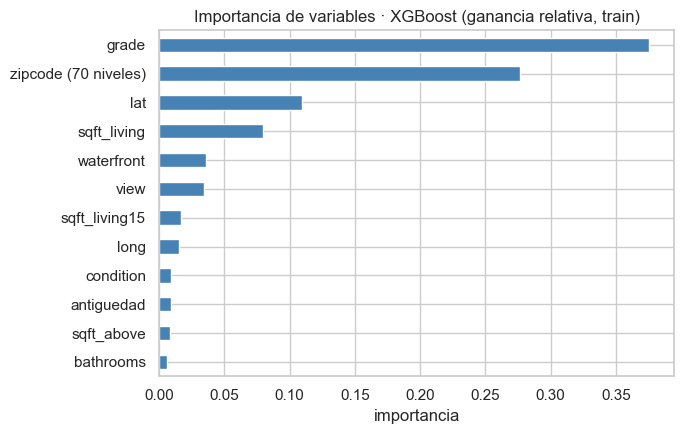

,importancia (ganancia relativa)
grade,0.376
zipcode (70 niveles),0.277
lat,0.109
sqft_living,0.079
waterfront,0.036
view,0.034
sqft_living15,0.017
long,0.015
condition,0.009
antiguedad,0.009


In [19]:
modelo_xgb = ajustados["XGBoost"].regressor_.named_steps["modelo"]
nombres_feat = ajustados["XGBoost"].regressor_.named_steps["prep"].get_feature_names_out()
imp = pd.Series(modelo_xgb.feature_importances_, index=nombres_feat)

agrupada = imp.groupby(lambda c: "zipcode (70 niveles)" if c.startswith("zipcode_") else c).sum().sort_values(ascending=False)
agrupada.round(4).to_frame("importancia").to_csv(TAB / "modelos_importancia_xgboost.csv")

fig, ax = plt.subplots(figsize=(7, 4.5))
agrupada.head(12)[::-1].plot.barh(ax=ax, color="steelblue")
ax.set_title("Importancia de variables · XGBoost (ganancia relativa, train)")
ax.set_xlabel("importancia")
plt.tight_layout()
guardar_fig("modelo_04_importancia_variables")
plt.show()
agrupada.head(10).round(3).to_frame("importancia (ganancia relativa)")

**Qué muestran los datos (validation, XGBoost)**
- **Error relativo:** mediana de −0.6 %; la mitad central de las ventas queda entre −8.6 % y +8.9 %, y el 90 % central entre −22 % y +33 %. Sobreestima por más de 20 % en el 11.0 % de las ventas y subestima por más de 20 % en el 6.8 %.
- **Por rango de precio:** el MdAPE va de 7.6 % (Q3) a 9.9 % (Q1) y 9.5 % (Q5). El sesgo cambia de signo: **+4.9 %** en las más baratas (sobreestima) y **−4.9 %** en las más caras (subestima). El MAE en dólares crece de 35 mil (Q1) a 139 mil (Q5).
- **Por modelo y rango:** Random Forest tiene menor MdAPE que XGBoost en Q1–Q3 (por ~0.2 a 0.3 puntos) y XGBoost en Q4–Q5 (por ~0.4 a 0.5 puntos).
- **Por zona:** entre los 62 códigos postales con ≥ 20 ventas, el MdAPE va de 4.7 % (98074) a 15.9 % (98166).
- **Importancia:** `grade` (0.38), `zipcode` (0.28), `lat` (0.11), `sqft_living` (0.08), `waterfront` (0.04), `view` (0.03).

**Interpretación**
- Los errores son aproximadamente simétricos alrededor de cero, con una cola algo más larga hacia la sobreestimación. El modelo predice mejor en el centro de la distribución de precios.
- El sesgo opuesto en los extremos es la señal típica de que el modelo **"se acerca al promedio"**: infla las casas baratas y deprecia las caras. Es una hipótesis compatible con los datos, no probada.
- La hipótesis del Paso 9 (XGBoost mejoraría sobre todo las casas caras) queda **débilmente apoyada**: su ventaja sobre Random Forest en MdAPE aparece solo en Q4–Q5 y es pequeña. No se contrastó con un intervalo por segmento.
- Entre códigos postales, los extremos de MdAPE se basan en 22 a 71 ventas, por lo que son ruidosos. Esa diferencia **no permite concluir** que el modelo falle sistemáticamente en una zona; se estudiará con más datos de error en el TF1.
- Las variables dominantes son calidad (`grade`), ubicación (`zipcode`, `lat`, `long`: en conjunto ~0.40) y tamaño, coherentes con el EDA y con el baseline por zona. **Precaución:** la importancia por ganancia se reparte entre variables correlacionadas (`grade`, `sqft_living` y `sqft_living15` están correlacionadas), por lo que `sqft_living` aparece con menos peso del que sugiere el EDA. No implica causalidad; SHAP en el TF1 permitirá un análisis más fino.

### 10.4 Evaluación final en test (una sola vez)
Modelo elegido con la regla fijada en el Paso 9 (**XGBoost**), junto a los baselines, evaluado en el test que no se usó para ajustar ni decidir.

,MAE (USD),RMSE (USD),R² (USD),R² (log),MdAPE (%),± 20 % (%)
B1 · Mediana global,234091.92,408336.75,-0.07,-0.01,34.33,30.18
B2 · Lineal simple (sqft_living),174748.65,299989.33,0.42,0.48,26.68,38.11
B3 · Regla por zona (USD/pie² × tamaño),101791.37,178862.32,0.80,0.79,14.03,65.17
XGBoost (elegido),66446.47,126804.60,0.90,0.91,8.58,82.91


XGBoost: validation vs test


,MAE (USD),RMSE (USD),R² (USD),R² (log),MdAPE (%),± 20 % (%)
validation,64948.68,112824.07,0.9,0.89,8.73,82.23
test,66446.47,126804.60,0.9,0.91,8.58,82.91


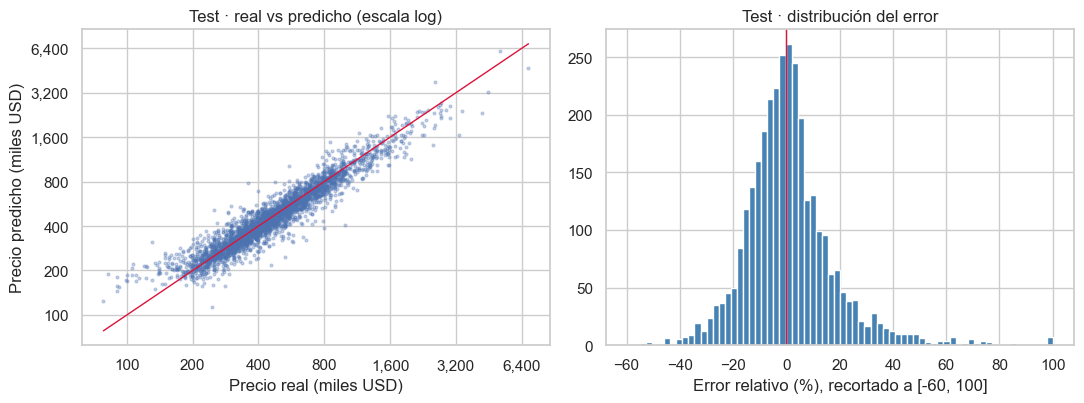

In [20]:
import joblib

pred_test = {
    "B1 · Mediana global": b1.predict(X_test),
    "B2 · Lineal simple (sqft_living)": b2.predict(X_test),
    "B3 · Regla por zona (USD/pie² × tamaño)": regla_zona(X_test),
    "XGBoost (elegido)": ajustados["XGBoost"].predict(X_test),
}
yt = y_test.to_numpy()
res_test = {k: evaluar(yt, p) for k, p in pred_test.items()}
tabla_test = pd.DataFrame(res_test).T
tabla_test.round(2).to_csv(TAB / "modelos_metricas_test_final.csv")
display(tabla_test.round(2))

print("XGBoost: validation vs test")
val_vs_test = pd.DataFrame({"validation": resultados_val["XGBoost"], "test": res_test["XGBoost (elegido)"]}).round(2).T
val_vs_test.to_csv(TAB / "modelos_xgboost_validation_vs_test.csv")
display(val_vs_test)

p_t = pred_test["XGBoost (elegido)"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(yt / 1e3, p_t / 1e3, s=4, alpha=.3)
lim = [yt.min() / 1e3, yt.max() / 1e3]
axes[0].plot(lim, lim, color="crimson", lw=1)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Precio real (miles USD)"); axes[0].set_ylabel("Precio predicho (miles USD)")
axes[0].set_title("Test · real vs predicho (escala log)"); ejes_miles(axes[0], "xy")
axes[1].hist(((p_t - yt) / yt * 100).clip(-60, 100), bins=70, color="steelblue")
axes[1].axvline(0, color="crimson", lw=1)
axes[1].set_xlabel("Error relativo (%), recortado a [-60, 100]"); axes[1].set_title("Test · distribución del error")
plt.tight_layout()
guardar_fig("modelo_05_real_vs_predicho_test")
plt.show()

In [21]:
# Intervalos del 95 % en test (bootstrap) y mejora relativa sobre B3
rng = np.random.default_rng(RANDOM_STATE)
p_x, p_b3 = pred_test["XGBoost (elegido)"], pred_test["B3 · Regla por zona (USD/pie² × tamaño)"]
nt = len(yt)
md_x, mae_x, red_mae, red_md = [], [], [], []
for _ in range(1000):
    i = rng.integers(0, nt, nt)
    ax, ab = np.abs(p_x[i] - yt[i]), np.abs(p_b3[i] - yt[i])
    mdx, mdb = np.median(ax / yt[i]) * 100, np.median(ab / yt[i]) * 100
    md_x.append(mdx); mae_x.append(ax.mean())
    red_mae.append(100 * (1 - ax.mean() / ab.mean())); red_md.append(100 * (1 - mdx / mdb))
r = lambda a: tuple(float(x) for x in np.percentile(a, [2.5, 97.5]).round(1))
print("XGBoost en test  | MdAPE 95 %:", r(md_x), "| MAE 95 %:", tuple(int(x) for x in np.percentile(mae_x, [2.5, 97.5])))
print("Reducción vs B3  | MAE (%) 95 %:", r(red_mae), "| MdAPE (%) 95 %:", r(red_md))
pd.DataFrame({
    "métrica": ["MdAPE XGBoost (%)", "MAE XGBoost (USD)", "Reducción de MAE vs B3 (%)", "Reducción de MdAPE vs B3 (%)"],
    "IC 95 % inferior": [np.percentile(md_x, 2.5), np.percentile(mae_x, 2.5), np.percentile(red_mae, 2.5), np.percentile(red_md, 2.5)],
    "IC 95 % superior": [np.percentile(md_x, 97.5), np.percentile(mae_x, 97.5), np.percentile(red_mae, 97.5), np.percentile(red_md, 97.5)],
}).round(1).to_csv(TAB / "modelos_intervalos_bootstrap_test.csv", index=False)

# Criterios de utilidad (Pasos 2 y 8)
x, b3 = res_test["XGBoost (elegido)"], res_test["B3 · Regla por zona (USD/pie² × tamaño)"]
v = resultados_val["XGBoost"]
criterios = pd.DataFrame([
    ("MdAPE en test ≤ 15 %", f"{x['MdAPE (%)']:.1f} %", x["MdAPE (%)"] <= 15),
    ("MAE ≥ 15 % menor que B3 (test)", f"{100*(1-x['MAE (USD)']/b3['MAE (USD)']):.1f} %", x["MAE (USD)"] <= 0.85 * b3["MAE (USD)"]),
    ("MdAPE ≥ 15 % menor que B3 (test)", f"{100*(1-x['MdAPE (%)']/b3['MdAPE (%)']):.1f} %", x["MdAPE (%)"] <= 0.85 * b3["MdAPE (%)"]),
    ("Estabilidad: |MdAPE val − test| ≤ 1 punto", f"{abs(v['MdAPE (%)']-x['MdAPE (%)']):.2f} pts", abs(v["MdAPE (%)"] - x["MdAPE (%)"]) <= 1),
], columns=["criterio", "valor", "cumple"])
criterios.to_csv(TAB / "modelos_criterios_utilidad.csv", index=False)
display(criterios)

joblib.dump(ajustados["XGBoost"], MODELS / "xgb_pipeline_tp1.joblib")
print("Modelo guardado en", (MODELS / "xgb_pipeline_tp1.joblib").relative_to(ROOT))

XGBoost en test  | MdAPE 95 %: (8.2, 9.1) | MAE 95 %: (63073, 70529)
Reducción vs B3  | MAE (%) 95 %: (31.8, 37.4) | MdAPE (%) 95 %: (35.3, 43.0)


,criterio,valor,cumple
0,MdAPE en test ≤ 15 %,8.6 %,True
1,MAE ≥ 15 % menor que B3 (test),34.7 %,True
2,MdAPE ≥ 15 % menor que B3 (test),38.9 %,True
3,Estabilidad: |MdAPE val − test| ≤ 1 punto,0.15 pts,True


Modelo guardado en models\xgb_pipeline_tp1.joblib


**Qué muestran los datos (test, evaluado una sola vez)**

| | MAE (USD) | RMSE (USD) | R² (USD) | MdAPE | ± 20 % |
|---|---|---|---|---|---|
| B1 · Mediana global | 234 092 | 408 337 | −0.07 | 34.3 % | 30.2 % |
| B2 · Lineal simple | 174 749 | 299 989 | 0.42 | 26.7 % | 38.1 % |
| B3 · Regla por zona | 101 791 | 178 862 | 0.80 | 14.0 % | 65.2 % |
| **XGBoost** | **66 446** | **126 805** | **0.90** | **8.6 %** | **82.9 %** |

- **Estabilidad:** el MdAPE pasa de 8.73 % (validation) a 8.58 % (test); el MAE, de 64 949 a 66 446. No hay señales de sobreajuste ni de fuga de información. El RMSE sube de 112 824 a 126 805, coherente con que el test contiene ventas más caras (hasta 6.9 millones).
- **Intervalos del 95 % (bootstrap en test):** MdAPE entre 8.2 % y 9.1 %. La reducción respecto de B3 es de **32 % a 37 %** en MAE y de **35 % a 43 %** en MdAPE.
- **Criterios de utilidad:** los cuatro criterios medibles se cumplen (tabla anterior). El criterio de explicabilidad básica se evaluó en 10.3: las variables dominantes tienen sentido en el dominio.

**Interpretación**
- Un modelo de aprendizaje **mejora de forma clara** a la mejor regla simple: en el caso típico se equivoca ~8.6 % del precio en lugar de ~14 %, y el 83 % de las ventas queda dentro de ±20 % (frente a 65 %).
- El resultado es consistente entre validation y test, y los intervalos no incluyen la mejora mínima exigida (15 %), por lo que es una mejora con respaldo estadístico.

**Qué no puede concluirse todavía**
- **Que el modelo funcione con ventas futuras o de otras zonas:** el split fue aleatorio y los datos son de un solo condado y ~13 meses (ver 6.1).
- **Que las variables importantes causen el precio:** la importancia describe qué usa el modelo, no qué lo determina.
- **Que las ventas con mayor error sean anomalías:** un error grande puede ser limitación del modelo (Paso 11 y TF1).
- **Que XGBoost sea mejor que Random Forest en todo:** empatan en el error relativo mediano; la ventaja es de ~4 900 USD en MAE, y es un resultado de una sola partición.

---
## 11. Primer vistazo a anomalías (exploratorio)

> Una venta con residuo grande puede ser una **venta atípica** o simplemente un **caso que el modelo no explica**. Este paso solo marca candidatas; no las confirma.

Se trabaja con **validation** (no se usó para ajustar el modelo) y no se vuelve a tocar el test. Dos criterios independientes:

| Criterio | Qué mide | Cómo se marca |
|---|---|---|
| **A · Residuo del modelo** | Cuánto se aleja el precio real de lo que XGBoost esperaba | Residuo en escala log, con umbral robusto: |r − mediana| > 3 × (1.4826 × MAD) |
| **B · Isolation Forest** | Qué tan inusual es la combinación de características **y** precio, sin usar el modelo de regresión | Se ajusta con *train*; se marcan en validation las `k` ventas más aisladas, con `k` igual al número marcado por A |

In [22]:
from sklearn.ensemble import IsolationForest

# --- Criterio A: residuo robusto en escala log (validation, XGBoost) ---
r = np.log(yv) - np.log(pred_val["XGBoost"])
mad = np.median(np.abs(r - np.median(r)))
z_rob = (r - np.median(r)) / (1.4826 * mad)
marca_A = np.abs(z_rob) > 3

print(f"Ventas en validation: {len(yv):,}")
print(f"Marcadas por A (|z robusto| > 3): {marca_A.sum()} ({marca_A.mean():.1%})")
print(f"  precio real MAYOR que el esperado: {(marca_A & (r > 0)).sum()} | MENOR que el esperado: {(marca_A & (r < 0)).sum()}")

# --- Criterio B: Isolation Forest ajustado SOLO con train ---
lp_train = np.log(y_train.to_numpy())
mu, sd = lp_train.mean(), lp_train.std()
Z_train = np.column_stack([prep.transform(X_train), (lp_train - mu) / sd])
Z_val = np.column_stack([prep.transform(X_val), (np.log(yv) - mu) / sd])

iso = IsolationForest(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(Z_train)
aislamiento = -iso.score_samples(Z_val)                  # mayor = más aislada
k = int(marca_A.sum())
marca_B = np.zeros(len(yv), bool)
marca_B[np.argsort(-aislamiento)[:k]] = True

solape = int((marca_A & marca_B).sum())
esperado = k * k / len(yv)
print(f"\nMarcadas por B (las {k} más aisladas): {marca_B.sum()}")
print(f"Marcadas por ambos criterios: {solape} | solape esperado por azar: {esperado:.1f}")

Ventas en validation: 3,242
Marcadas por A (|z robusto| > 3): 128 (3.9%)
  precio real MAYOR que el esperado: 40 | MENOR que el esperado: 88



Marcadas por B (las 128 más aisladas): 128
Marcadas por ambos criterios: 18 | solape esperado por azar: 5.1


In [23]:
vv = X_val.assign(
    id=df.loc[mask_val, "id"].to_numpy(), fecha=df.loc[mask_val, "fecha"].to_numpy(),
    real=yv, pred=pred_val["XGBoost"].round(0), error_pct=((pred_val["XGBoost"] - yv) / yv * 100).round(1),
    z_robusto=z_rob.round(1), marca_A=marca_A, marca_B=marca_B,
    dato_dudoso=df.loc[mask_val, "dato_dudoso"].to_numpy(),
    id_repetido=df.loc[mask_val, "id"].duplicated(keep=False).to_numpy() | df.loc[mask_val, "id"].isin(df.loc[~mask_val, "id"]).to_numpy(),
)
cols = ["real", "pred", "error_pct", "z_robusto", "sqft_living", "grade", "zipcode", "waterfront", "marca_B", "id_repetido"]
top = vv.loc[marca_A].reindex(vv.loc[marca_A, "z_robusto"].abs().sort_values(ascending=False).index)
top[cols].head(12)

,real,pred,error_pct,z_robusto,sqft_living,grade,zipcode,waterfront,marca_B,id_repetido
7992,90000.0,249906.0,177.7,-7.9,780,5,98108,0,False,False
21050,900000.0,2379302.0,164.4,-7.5,7120,12,98006,0,True,False
12823,145000.0,378950.0,161.3,-7.4,800,6,98033,0,False,False
18848,380000.0,954061.0,151.1,-7.1,1980,10,98166,1,True,False
465,80000.0,194724.0,143.4,-6.9,430,4,98014,0,True,False
6831,350000.0,838754.0,139.6,-6.8,3380,8,98118,0,False,False
8450,425000.0,970005.0,128.2,-6.4,3610,8,98023,1,True,False
4024,800000.0,1812655.0,126.6,-6.3,7480,11,98166,0,True,False
12377,107000.0,241022.0,125.3,-6.3,910,6,98106,0,False,True
1385,250000.0,566632.0,126.7,-6.3,2840,8,98056,0,False,False


,marcadas por A,resto
real,320000.0,450000.0
sqft_living,1500.0,1900.0
grade,7.0,7.0
% con id repetido,9.4,1.3
% con dato_dudoso,0.0,0.1
% waterfront,2.3,0.9


Marcadas por A según quintil de precio real: {'Q1': 58, 'Q2': 22, 'Q3': 16, 'Q4': 12, 'Q5': 20}


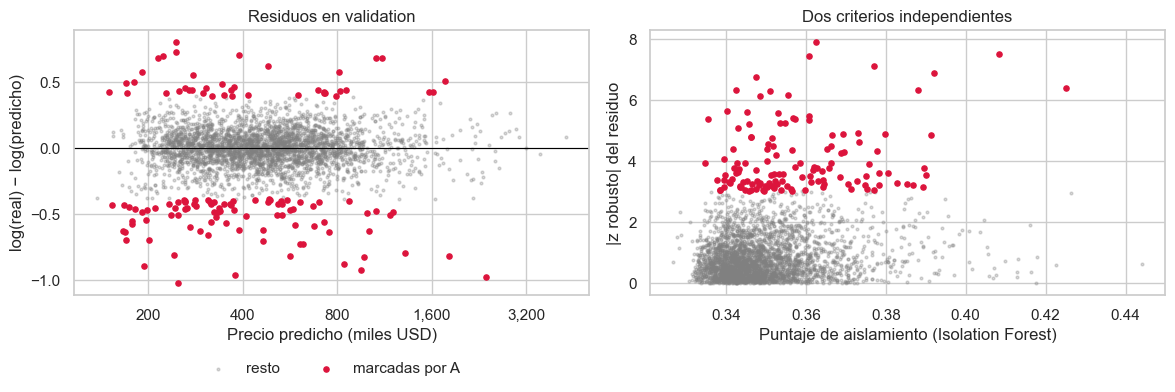

In [24]:
resumen_cmp = pd.DataFrame({
    "marcadas por A": vv.loc[marca_A, ["real", "sqft_living", "grade"]].median(),
    "resto": vv.loc[~marca_A, ["real", "sqft_living", "grade"]].median(),
})
resumen_cmp.loc["% con id repetido"] = [100 * vv.loc[marca_A, "id_repetido"].mean(), 100 * vv.loc[~marca_A, "id_repetido"].mean()]
resumen_cmp.loc["% con dato_dudoso"] = [100 * vv.loc[marca_A, "dato_dudoso"].mean(), 100 * vv.loc[~marca_A, "dato_dudoso"].mean()]
resumen_cmp.loc["% waterfront"] = [100 * vv.loc[marca_A, "waterfront"].mean(), 100 * vv.loc[~marca_A, "waterfront"].mean()]
display(resumen_cmp.round(1))

q = pd.qcut(vv["real"], 5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"])
print("Marcadas por A según quintil de precio real:", vv.loc[marca_A].groupby(q[marca_A], observed=False).size().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(pred_val["XGBoost"][~marca_A] / 1e3, r[~marca_A], s=4, alpha=.3, color="gray", label="resto")
axes[0].scatter(pred_val["XGBoost"][marca_A] / 1e3, r[marca_A], s=14, color="crimson", label="marcadas por A")
axes[0].axhline(0, color="black", lw=.8)
axes[0].set_xscale("log"); axes[0].set_xlabel("Precio predicho (miles USD)"); axes[0].set_ylabel("log(real) − log(predicho)")
axes[0].set_title("Residuos en validation"); ejes_miles(axes[0], "x")
axes[0].legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
axes[1].scatter(aislamiento[~marca_A], np.abs(z_rob)[~marca_A], s=4, alpha=.3, color="gray")
axes[1].scatter(aislamiento[marca_A], np.abs(z_rob)[marca_A], s=14, color="crimson")
axes[1].set_xlabel("Puntaje de aislamiento (Isolation Forest)"); axes[1].set_ylabel("|z robusto| del residuo")
axes[1].set_title("Dos criterios independientes")
plt.tight_layout()
guardar_fig("anomalias_01_residuos_e_isolation_forest")
plt.show()

top[cols].to_csv(TAB / "anomalias_candidatas_validation.csv")

**Qué muestran los datos (validation, 3 242 ventas)**
- El criterio A marca **128 ventas (3.9 %)**. De ellas, **88 (69 %)** se vendieron **por debajo** del precio esperado y 40 por encima.
- Entre las 12 más extremas, 11 son ventas muy por debajo de lo esperado. Por ejemplo: una casa de 7 120 pies² y grade 12 vendida en 900 mil cuando el modelo esperaba 2.38 millones, o una de 780 pies² vendida en 90 mil frente a 250 mil esperados.
- Las marcadas son **más baratas** (mediana 320 mil frente a 450 mil) y más pequeñas (1 500 frente a 1 900 pies²), con el mismo `grade` mediano (7). **58 de las 128 (45 %)** están en el quintil de precios más bajo, que concentra el 20 % de las ventas.
- Entre las marcadas, el **9.4 %** corresponde a viviendas vendidas más de una vez, frente al **1.3 %** del resto. Ninguna tiene `dato_dudoso`.
- Los dos criterios coinciden en **18** ventas; por azar se esperarían ~5.

**Interpretación**
- El modelo detecta sobre todo ventas **más baratas de lo esperado**, coherente con el sesgo del Paso 10 (sobreestima las casas baratas). Una parte de los "candidatos" puede deberse a esa limitación del modelo y no a ventas realmente atípicas.
- La **coincidencia entre criterios es modesta** (3.5 veces la esperada por azar, pero solo 18 de 128): miden cosas distintas. A mira qué tan lejos está el precio de lo esperado; B mira qué tan rara es la combinación de características y precio.
- El **enriquecimiento de ventas repetidas** (9.4 % frente a 1.3 %) es consistente con la hipótesis del Paso 3: reventas rápidas o compras para revender, donde la primera venta ocurre bajo el valor de mercado. Es la única pista respaldada por datos; el resto es especulación.
- Otras explicaciones posibles, **no verificables con este dataset**: ventas con condiciones especiales (entre familiares, remates), estado interior de la vivienda no registrado, o errores de registro del precio.

**Límites de este paso**
- No existe una etiqueta de "anomalía real": no se pueden calcular precisión ni *recall*. Es una **lista de candidatas para revisión**, no una detección validada.
- El umbral (3 desviaciones robustas) es arbitrario y se aplicó sobre una sola partición de validación.
- Una venta marcada **no** es un error ni un fraude; solo indica que el modelo no la explica con las variables disponibles.

---
## 12. Estado del proyecto y plan hacia el TF1

### 12.1 Principales hallazgos hasta el momento
1. **Un modelo de aprendizaje mejora de forma clara a la mejor regla simple.** En test, XGBoost logra MdAPE 8.6 % y MAE 66 mil USD, frente a 14.0 % y 102 mil de la regla por zona; la reducción de error es de 32–37 % (MAE) y 35–43 % (MdAPE) con intervalos del 95 %.
2. **Ubicación, calidad y tamaño explican casi todo el precio.** Una regla de dos ingredientes (zona × tamaño) ya llega a R² 0.80; en XGBoost dominan `grade` (0.38), `zipcode` (0.28) y `lat` (0.11).
3. **Ridge se acerca bastante a los árboles** (MdAPE 10.1 % frente a 8.7 % en validation); la mejora de los árboles es real pero moderada.
4. **Random Forest y XGBoost empatan** en error relativo mediano; solo difieren en MAE (~4 900 USD a favor de XGBoost).
5. **El error no es uniforme:** el modelo sobreestima las casas baratas (+4.9 %) y subestima las caras (−4.9 %), y el MdAPE por código postal va de 4.7 % a 15.9 %.
6. **Un pequeño grupo de ventas no se explica:** el 3.9 % de validation queda marcado por el residuo, en su mayoría ventas más baratas de lo esperado y con más reventas repetidas de lo normal.

### 12.2 Problemas no resueltos y limitaciones
| Tema | Limitación | Efecto |
|---|---|---|
| **Alcance de los datos** | Un condado, ~13 meses, sin variables de entorno ni del estado interior | El modelo no se puede extrapolar a otras zonas ni a ventas futuras |
| **Validación** | Una sola partición aleatoria; sin validación temporal | Las diferencias entre modelos (por ejemplo RF y XGBoost) están dentro del ruido de una partición |
| **Hiperparámetros** | Valores por defecto o casi por defecto | El desempeño de los modelos de árboles es probablemente subóptimo |
| **`zipcode`** | *One-hot* de 70 niveles (el menos frecuente tiene 50 ventas) | Agrega 70 columnas dispersas; la ubicación podría representarse mejor |
| **Sesgo en los extremos** | Regresión hacia el promedio | Subestima las casas caras, las que más importan en dólares |
| **Anomalías** | Sin etiqueta real; umbral arbitrario; los candidatos se mezclan con errores del modelo | No se puede medir la calidad de la detección |
| **Uso del test** | El test ya se evaluó una vez para el TP1 | En el TF1 no debe usarse para decidir nada; solo para una evaluación final |
| **Umbral de utilidad** | La mejora de al menos 15 % sobre B3 (en MAE y MdAPE) fue aceptada por el grupo | Criterio de éxito confirmado |

### 12.3 Plan hacia el TF1
Cada tarea parte de una evidencia del TP1.

| # | Tarea | Motivo (evidencia del TP1) | Criterio de éxito |
|---|---|---|---|
| 1 | **Validación cruzada agrupada por `id`** (`GroupKFold`) sobre train + validation | Las diferencias entre modelos se midieron en una sola partición | Intervalos por pliegue; decidir con CV y no con una partición |
| 2 | **Optimización de hiperparámetros con Optuna** (XGBoost y Random Forest), con registro en **MLflow** | Hiperparámetros sin ajustar; RF y XGBoost empatan | Cada resultado reproducible desde su configuración registrada |
| 3 | **Clustering de zonas** (K-Means / DBSCAN sobre `lat`/`long`) y **PCA** si aporta | La ubicación explica ~40 % de la importancia; `zipcode` suma 70 columnas; el error por zona varía de 4.7 % a 15.9 % | Que las zonas por clustering reemplacen o complementen a `zipcode` y reduzcan el error o la dimensión; si no mejoran, se descarta y se documenta |
| 4 | **Interpretabilidad con SHAP** (global y local) | La importancia por ganancia se reparte entre variables correlacionadas (`grade`, `sqft_living`, `sqft_living15`) | Explicaciones coherentes con el dominio y con el EDA; precauciones documentadas |
| 5 | **Análisis de errores en profundidad** | Sesgo ±4.9 % en los extremos; error desigual por zona | Hipótesis separadas de la evidencia, con casos concretos |
| 6 | **Anomalías sobre todo el dataset**, con residuos *out-of-fold*; revisar el patrón de reventas (precio de compra frente a reventa) | El 9.4 % de las marcadas son ventas repetidas, frente a 1.3 % del resto | Lista de candidatas revisada; hipótesis de reventas contrastada con datos |
| 7 | **Validación temporal** como prueba de robustez | El split aleatorio no mide el desempeño con ventas futuras | Comparar el error con el del split aleatorio y documentar la diferencia |
| 8 | **Aplicación (Streamlit)** que carga el pipeline guardado y predice a partir de las características de una vivienda | El enunciado exige una demostración utilizable | Predicción visible, conectada al pipeline, con aviso de las limitaciones |
| 9 | **Reentrenar con train + validation** para el modelo final, y **una única evaluación en test** | Aprovechar los datos disponibles sin contaminar el test | Métricas finales en test, reportadas una vez |
| 10 | **Documentación final**: README, tabla de evolución TP1 → TF1, diagrama de arquitectura, decisiones de herramientas | Entregables del TF1 | Otra persona puede reproducir el proyecto |

### 12.4 Decisiones pendientes para el grupo
1. **Umbral de utilidad (decidido):** el grupo aceptó "mejora de al menos 15 % sobre el mejor baseline", medida en MAE y en MdAPE.
2. **Alcance de la técnica adicional:** ¿clustering de zonas, PCA o ambas? Solo se conservan si mejoran el resultado.
3. **Uso del test en el TF1:** se propone mantenerlo intacto y evaluarlo solo al final.
4. **Formato de la aplicación:** Streamlit (propuesto) o API con FastAPI.